In [4]:
import kagglehub

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [5]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('dog-breed-identification')
# kaggle token: KGAT_1cd1d07902bf3e5316619e52ead90228

print("Path to competition files:", path)

100%|██████████| 691M/691M [00:08<00:00, 85.7MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/dog-breed-identification


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
import tensorflow_hub as hub

In [7]:
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs:", len(physical_devices))

Num GPUs: 1


In [8]:
labels_csv = pd.read_csv(f"{path}/labels.csv")

In [9]:
labels_csv

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever
...,...,...
10217,ffd25009d635cfd16e793503ac5edef0,borzoi
10218,ffd3f636f7f379c51ba3648a9ff8254f,dandie_dinmont
10219,ffe2ca6c940cddfee68fa3cc6c63213f,airedale
10220,ffe5f6d8e2bff356e9482a80a6e29aac,miniature_pinscher


In [10]:
labels_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


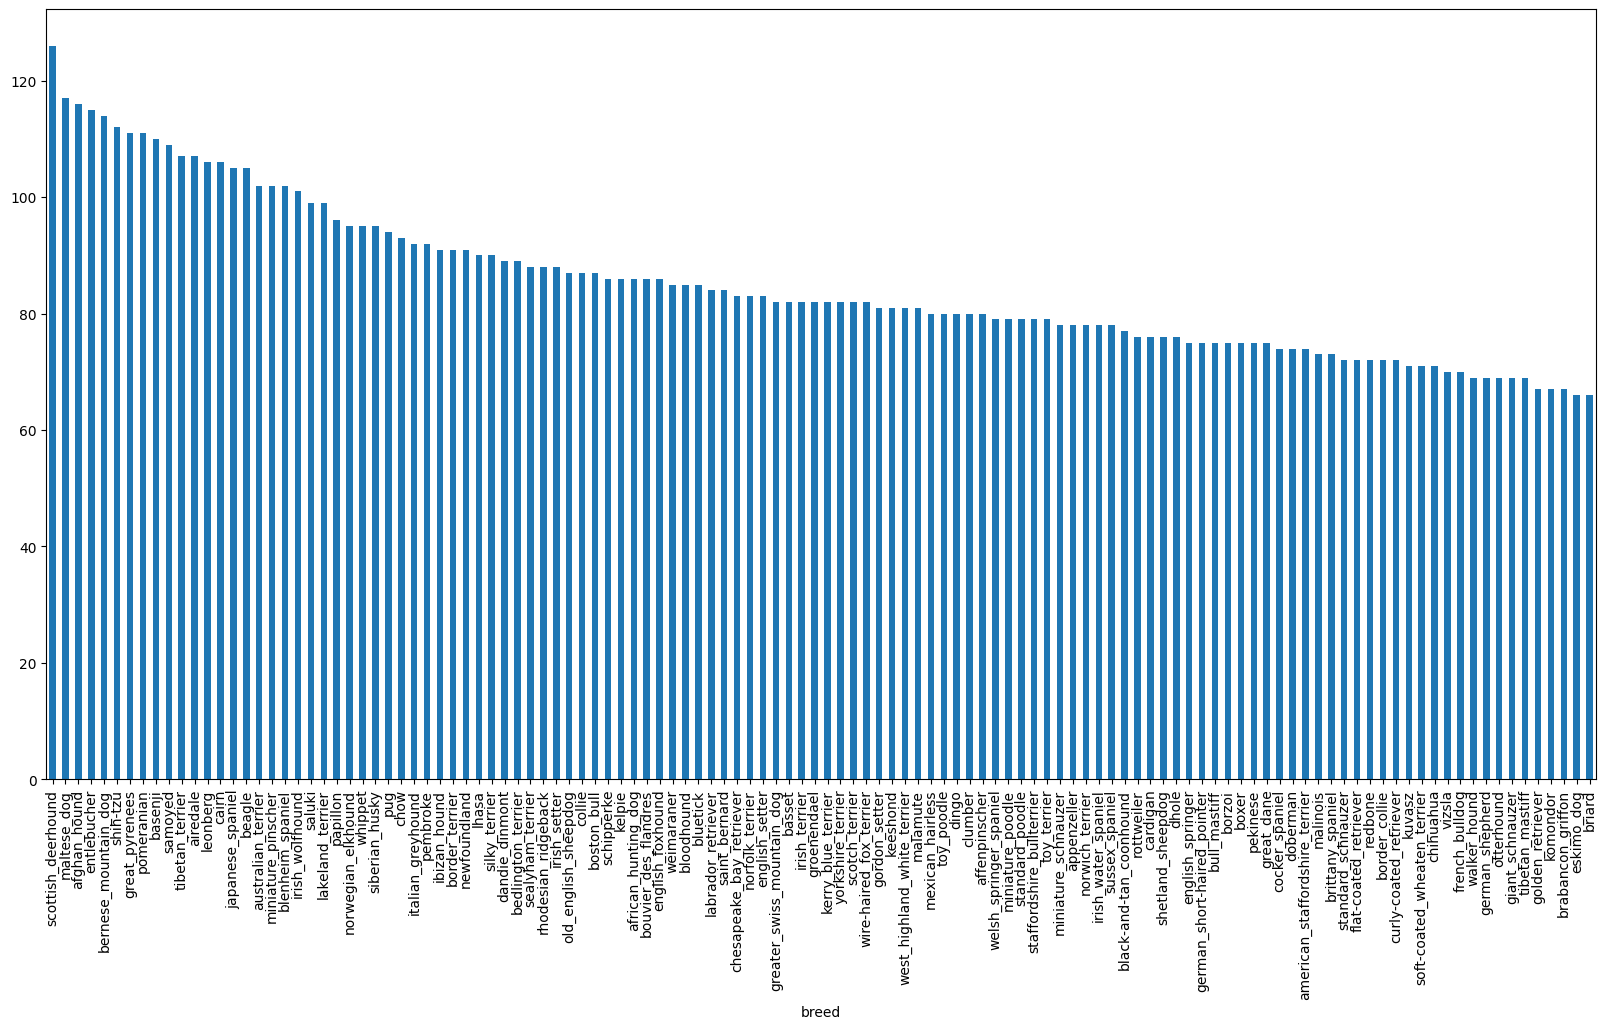

In [11]:
labels_csv.breed.value_counts().plot.bar(figsize=(20, 10))

plt.show()

In [12]:
labels_csv.breed.value_counts().median()

82.0

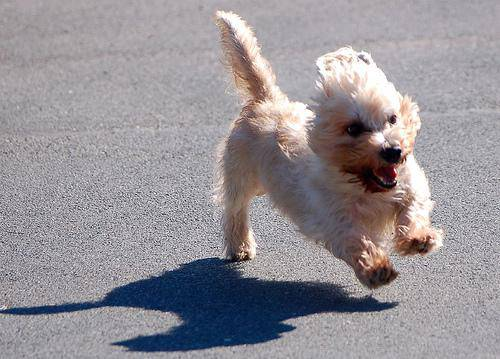

In [13]:
from IPython.display import Image
Image(f"{path}/train/ffd3f636f7f379c51ba3648a9ff8254f.jpg")

In [14]:
image_pathnames = np.array([f"{path}/train/{fname}.jpg" for fname in labels_csv.id])

In [15]:
import os

if (len(os.listdir(f"{path}/train")) == len(image_pathnames)):
  print("Filenames match actual amount of files! Proceed")
else:
  print("Filenames do not match the amount of files")

Filenames match actual amount of files! Proceed


In [16]:
labels = np.array(labels_csv['breed'])

In [17]:
len(labels)

10222

In [18]:
if len(labels) == len(image_pathnames):
  print("Labels match the amount of files! Proceed")
else:
  print("Labels do not match the amount of files")

Labels match the amount of files! Proceed


In [19]:
unique_labels = np.unique(labels)
len(unique_labels)

120

In [20]:
# this is technically one hot encoding but by hand
boolean_labels = np.array([label == unique_labels for label in labels])

In [21]:
boolean_labels[:2]

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, Fals

## Create X and y Variables

In [22]:
X = image_pathnames
y = boolean_labels

We are going to start off experimenting with ~1000 images and increase as needed

In [165]:
NUM_IMAGES = 10000 #@param {type:"slider", min:1000, max:10000}

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X[:NUM_IMAGES],
    y[:NUM_IMAGES],
    test_size=.2,
    random_state=42
)

In [167]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((8000,), (8000, 120), (2000,), (2000, 120))

## Turning Images into Tensors

In [168]:
# convert an image into numpy array
from matplotlib.pyplot import imread

image = imread(X_val[42])
image.shape

(254, 202, 3)

In [215]:
IMG_SIZE = 224 # (224, 224)

# create a function for preprocessing images
def process_image(image_path, img_size=IMG_SIZE):
  image = tf.io.read_file(image_path)
  # turn the jpeg image to Tensor with 3 color channels
  image = tf.image.decode_jpeg(image, channels=3)
  image = image/255
  # resize the image
  image = tf.image.resize(image, size=[img_size, img_size])
  return image


We need our data in the form of Tensor tuples:
`(image_tensor, label)`

In [170]:
def get_image_tuple(image_path, label):
  image = process_image(image_path, 224)
  return image, label

In [171]:
BATCH_SIZE = 32

# can take both X_train, and X_test
def create_data_batches(X, y=None, batch_size = BATCH_SIZE, valid_data=False, test_data=False):
  # can also accept test data, where there are no labels
  if test_data:
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X))) # no labels
    data_batch = data.map(process_image).batch(batch_size)
    return data_batch
  elif valid_data:
    data = tf.data.Dataset.from_tensor_slices(
     (tf.constant(X), tf.constant(y)),
    )
    data = data.map(get_image_tuple).batch(batch_size)
    return data
  else:
    # training _data
    data = tf.data.Dataset.from_tensor_slices(
      (tf.constant(X), tf.constant(y)),
    )
    data = data.shuffle(buffer_size=len(X))
    # get_image_tuple this also turns the image path into a preprocessed image
    data = data.map(get_image_tuple).batch(batch_size)
  return data

In [172]:
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

In [173]:
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## Visaulizing Data Batches

In [174]:
def show_25_images(images, labels):
    fig = plt.figure(figsize=(10, 10))  # plt.figure(), not plt.Figure()
    for i in range(25):
        ax = fig.add_subplot(5, 5, i+1, xticks=[], yticks=[])
        ax.imshow(images[i])
        ax.set_title(unique_labels[labels[i].argmax()])  # ax.set_title(), not plt.title()
    plt.show()

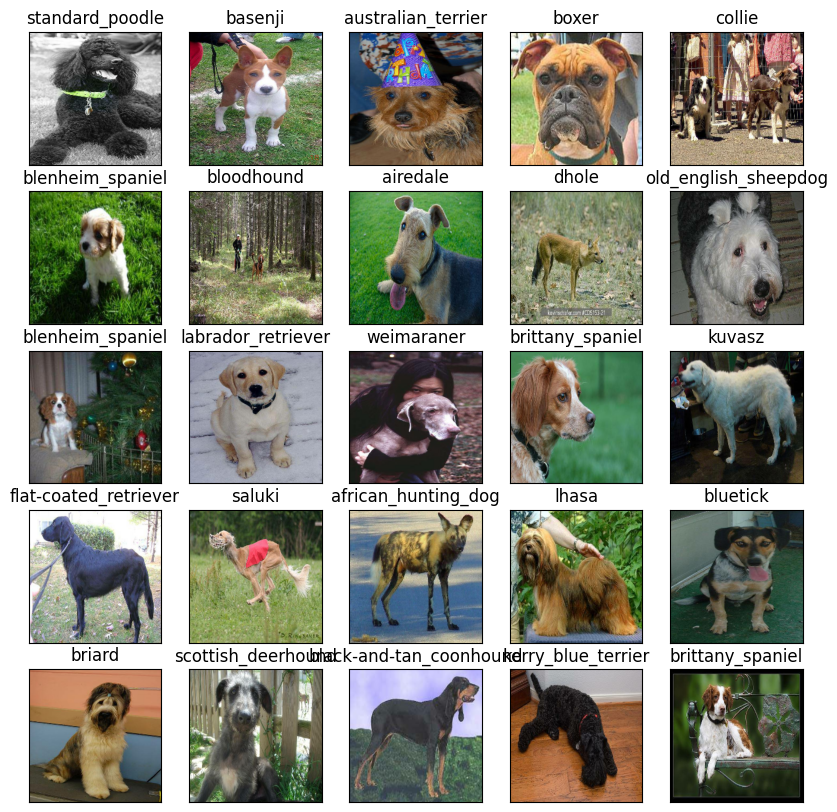

In [175]:
train_images, train_labels = next(train_data.as_numpy_iterator())
show_25_images(train_images, train_labels)

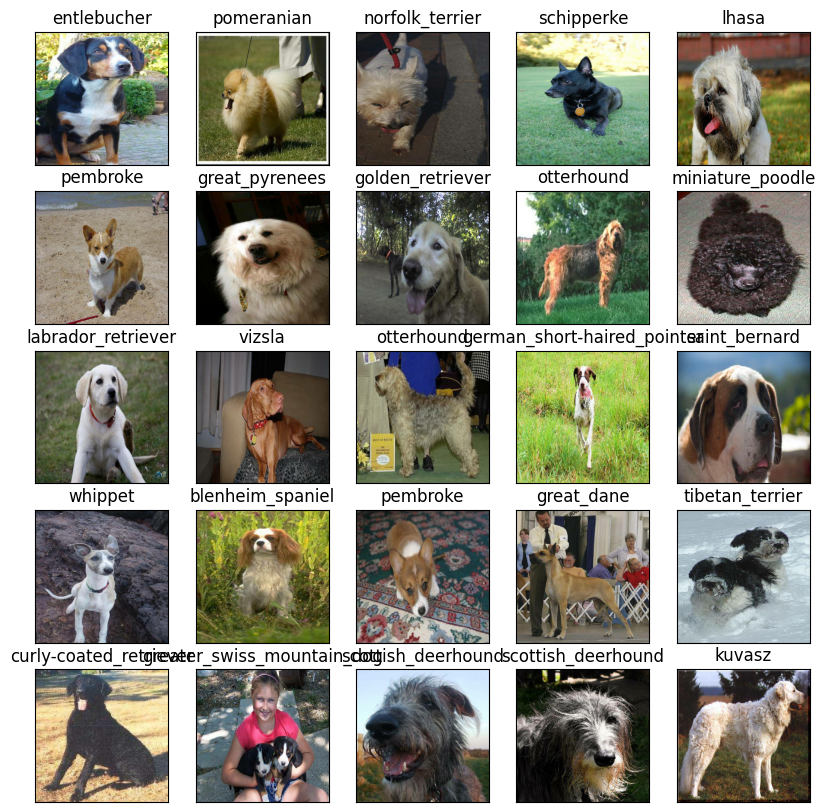

In [176]:
val_images, val_labels = next(val_data.as_numpy_iterator())
show_25_images(val_images, val_labels)

## Building the model

In [177]:
# setup input shape to the model
INPUT_SHAPE = [None, IMG_SIZE, IMG_SIZE, 3] # batch, height, width, color channels

# output shape of the model how like softmax probabilities of total unique_labels (y)
OUTPUT_SHAPE = len(unique_labels)

# model URL from tensorflow hub
MODEL_URL = "https://kaggle.com/models/google/mobilenet-v2/TensorFlow2/130-224-classification/1"


In [178]:
# keras model
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
  model = tf.keras.Sequential(
      [
          hub.KerasLayer(model_url),
          tf.keras.layers.Dense(units=OUTPUT_SHAPE, activation="softmax"),
      ]
  )

  model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
  )

  model.build(input_shape)

  return model

In [179]:
model = create_model()

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1001)              5432713   
                                                                 
 dense_1 (Dense)             (None, 120)               120240    
                                                                 
Total params: 5552953 (21.18 MB)
Trainable params: 120240 (469.69 KB)
Non-trainable params: 5432713 (20.72 MB)
_________________________________________________________________


In [180]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

In [181]:
EPOCHS = 100

model.fit(train_data, epochs=EPOCHS, validation_data=val_data, validation_freq=1, callbacks=[early_stopping])

Epoch 1/100
250/250 [==============================] - 25s 84ms/step - loss: 1.5067 - accuracy: 0.6363 - val_loss: 0.7395 - val_accuracy: 0.7750
Epoch 2/100
250/250 [==============================] - 18s 71ms/step - loss: 0.4082 - accuracy: 0.8844 - val_loss: 0.6813 - val_accuracy: 0.7835
Epoch 3/100
250/250 [==============================] - 18s 70ms/step - loss: 0.2264 - accuracy: 0.9451 - val_loss: 0.6656 - val_accuracy: 0.7900
Epoch 4/100
250/250 [==============================] - 18s 71ms/step - loss: 0.1444 - accuracy: 0.9719 - val_loss: 0.6631 - val_accuracy: 0.7960
Epoch 5/100
250/250 [==============================] - 20s 81ms/step - loss: 0.0994 - accuracy: 0.9836 - val_loss: 0.6681 - val_accuracy: 0.7980
Epoch 6/100
250/250 [==============================] - 18s 70ms/step - loss: 0.0711 - accuracy: 0.9899 - val_loss: 0.6710 - val_accuracy: 0.7950
Epoch 7/100
250/250 [==============================] - 19s 77ms/step - loss: 0.0532 - accuracy: 0.9946 - val_loss: 0.6840 - val_ac

In [182]:
predictions = model.predict(val_data, verbose=1)
predictions

63/63 [==============================] - 5s 62ms/step


array([[2.05260586e-09, 1.03144944e-10, 2.85587176e-09, ...,
        2.72590839e-09, 1.14358969e-07, 1.29624186e-10],
       [1.90745050e-06, 1.49417488e-07, 1.20371568e-09, ...,
        2.81112800e-10, 1.58871383e-09, 3.63060906e-08],
       [3.98034090e-03, 2.38003631e-05, 1.01516111e-04, ...,
        5.22598248e-06, 2.42328140e-04, 8.19588546e-03],
       ...,
       [2.24276409e-05, 3.32397976e-05, 4.74061579e-07, ...,
        1.70215335e-05, 2.75041712e-05, 3.10097379e-03],
       [5.88149938e-08, 4.75300688e-09, 8.98211017e-09, ...,
        6.77983337e-07, 4.15965274e-04, 9.36406508e-08],
       [2.21060162e-07, 3.30967923e-05, 2.29550956e-09, ...,
        1.21836941e-08, 3.20619779e-06, 6.56415796e-06]], dtype=float32)

In [183]:
# single prediction
index = 23
print(predictions[index])
print(f"Max value (propability of prediction): {np.max(predictions[index])}")
print(f"Sum: {np.sum(predictions[index])}")
print(f"Max Index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_labels[np.argmax(predictions[index])]}")

[1.60932245e-06 1.25598417e-05 1.06292237e-06 7.38421477e-07
 2.70595166e-07 2.02781348e-06 6.73490104e-06 2.23409469e-08
 9.24676624e-06 9.32731403e-09 4.59963712e-06 3.96968858e-07
 3.50816777e-06 3.22558726e-08 8.02113647e-08 4.35332282e-07
 7.99372992e-06 1.28849507e-07 3.24746734e-03 1.47174548e-08
 3.77075580e-08 4.52780313e-10 1.60062683e-08 8.62537661e-07
 7.07985315e-09 5.78668780e-10 2.53035682e-06 9.71502132e-08
 2.30940733e-09 1.56374735e-09 1.36595597e-08 1.70424940e-07
 6.43009512e-09 1.62124721e-04 4.16770476e-08 2.04213677e-07
 4.27812711e-06 3.42648256e-08 5.20982780e-07 1.51265192e-06
 6.10538677e-07 3.25194549e-07 1.13387832e-08 3.30535532e-09
 3.44759496e-06 3.62563490e-09 2.68716576e-07 7.77179139e-07
 1.14561306e-06 4.14567225e-08 7.24344943e-07 9.86624116e-08
 6.24406837e-08 1.79989392e-08 1.29013179e-05 3.37144826e-04
 2.56005205e-06 2.01535804e-05 9.03555009e-09 1.84028919e-04
 2.87491730e-06 1.44513042e-08 2.95388895e-06 2.90671352e-07
 1.19141326e-07 7.170741

In [184]:
# Turn probabilities into their respective label (easier to understand)

def get_pred_label(prediction_probabilities):
  return unique_labels[np.argmax(prediction_probabilities)]

In [185]:
pred_label = get_pred_label(predictions[0])
pred_label

'entlebucher'

*Unbatch the validation data to make predictions on the validation dataset and compare these predictions to original 'y' value of validation dataset*

In [186]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [187]:
def unbatchify(val_data):
  images = []
  labels = []

  for image, label in val_data.unbatch().as_numpy_iterator():
    images.append(image)
    labels.append(unique_labels[np.argmax(label)])
  return images, labels

In [188]:
val_images_, val_labels_ = unbatchify(val_data)

In [189]:
get_pred_label(val_labels_[0])

'affenpinscher'

In [190]:
get_pred_label(predictions[0])

'entlebucher'

## Plotting Predictions

In [191]:
# ploting the single prediction
def plot_pred(prediction_probabilities, labels, images, n=1):
  # view the prediction, ground truth, and image for sample n
  pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

  pred_label = get_pred_label(pred_prob)

  if pred_label==true_label:
    color='green'
  else:
    color='red'

  plt.imshow(image)
  plt.title(f"P: {pred_label} | {np.max(pred_prob)*100:.2f}% | A: {true_label}", color=color)
  plt.axis(False)

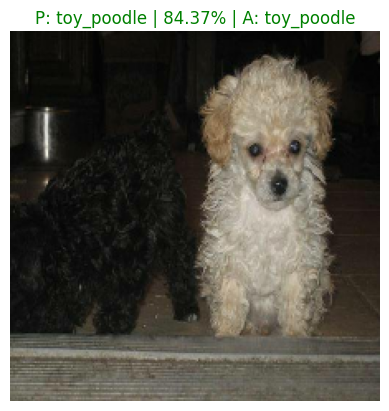

In [201]:
plot_pred(predictions, val_labels_, val_images_, n=76)

## Plot models top 10 Predictions

In [193]:
def plot_pred_top_10(prediction_probabilities, labels, n=1):
  # view the top 10 highest prediction confidences, ground truth, and image for sample n
  pred_prob, true_label = prediction_probabilities[n], labels[n]

  pred_label = get_pred_label(pred_prob)

  # top 10 predictions of single prediction
  top_10_indexes = pred_prob.argsort()[-10:][::-1]

  top_10_predictions = pred_prob[top_10_indexes]
  top_10_labels = unique_labels[top_10_indexes]

  # setup the plots
  top_plot = plt.bar(
      np.arange(len(top_10_predictions)),
      top_10_predictions,
      tick_label=top_10_labels,
      color='grey'
  )

  plt.xticks(rotation='vertical')

  # change the color of true label
  if np.isin(true_label, top_10_labels):
    top_plot[np.argmax(top_10_labels == true_label)].set_color('green')
  else:
    pass

  if pred_label==true_label:
    color='green'
  else:
    color='red'

  plt.title(f"P: {pred_label} | A: {true_label}", color=color)
  plt.xlabel("Predictions")
  plt.ylabel("Prediction probability")

  plt.show()

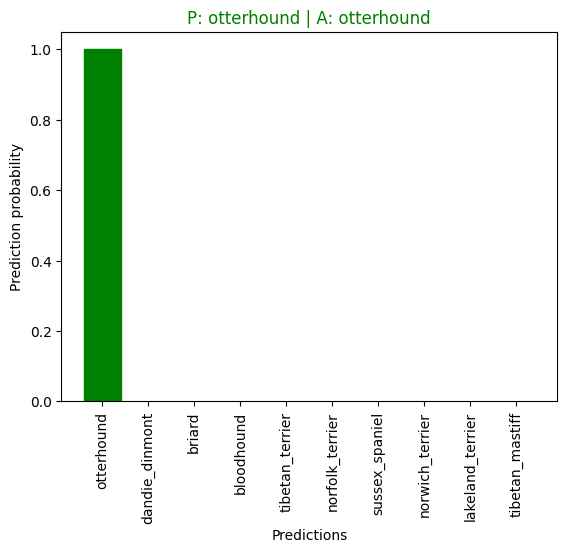

In [200]:
plot_pred_top_10(predictions, val_labels_, n=8)

## Saving our trained model

In [195]:
import datetime

def save_model(model, suffix=''):
  modeldir = os.path.join("./models", datetime.datetime.now().strftime("%Y%m%d-%H%M%s"))

  model_path = modeldir + '-' + suffix + '.h5'
  model.save(model_path)
  return model_path

In [196]:
def load_model(model_path):
  return tf.keras.models.load_model(model_path, custom_objects={"KerasLayer":hub.KerasLayer})

In [197]:
model_path = save_model(model, suffix='10000-images')

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [198]:
loaded_model = load_model(model_path)

In [199]:
loaded_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_1 (KerasLayer)  (None, 1001)              5432713   
                                                                 
 dense_1 (Dense)             (None, 120)               120240    
                                                                 
Total params: 5552953 (21.18 MB)
Trainable params: 120240 (469.69 KB)
Non-trainable params: 5432713 (20.72 MB)
_________________________________________________________________


## Make Predictions on Test Data

- get the test image filenames
- convert the filenames into test data batches using `create_data_batches` and setting the `test_data` parameter to `True` (since the test data doesn't have labels)
Predict by passing the data into `predict` method


In [216]:
# load test image filenames
test_path = f"{path}/test"
test_filenames = [f"{test_path}/{fname}" for fname in os.listdir(test_path)]

In [218]:
test_data = create_data_batches(test_filenames, test_data=True, )

In [220]:
test_predictions = loaded_model.predict(test_data, verbose=1)

324/324 [==============================] - 20s 60ms/step


In [221]:
test_predictions

array([[1.2658866e-06, 2.6135458e-02, 1.1855600e-04, ..., 1.9393886e-03,
        6.2846707e-06, 1.2043498e-05],
       [8.4116709e-06, 6.9117099e-09, 5.6557337e-07, ..., 9.9458648e-06,
        8.1933558e-06, 1.4109855e-06],
       [1.4976214e-06, 1.4877933e-06, 2.3205571e-08, ..., 3.6074751e-05,
        7.8567473e-04, 1.6089720e-06],
       ...,
       [3.8720477e-10, 1.0142047e-08, 1.8452249e-10, ..., 7.3991090e-05,
        7.4740889e-08, 1.5470670e-07],
       [5.3323224e-06, 1.4916045e-06, 3.7193706e-06, ..., 4.0275145e-07,
        2.3157498e-02, 2.8197013e-04],
       [3.7390149e-05, 1.2290427e-06, 5.5007621e-07, ..., 1.5760322e-07,
        1.2254795e-07, 2.0481586e-05]], dtype=float32)

In [223]:
np.savetxt('./test_preds', test_predictions, delimiter=',')

In [224]:
test_predictions_loaded = np.loadtxt('./test_preds', delimiter=',')

In [228]:
predicted_labels_for_test = []
for test_prediciton in test_predictions:
  predicted_labels_for_test.append(get_pred_label(test_prediciton))
len(predicted_labels_for_test)

10357

In [230]:
predicted_labels_for_test[:10]

['tibetan_terrier',
 'boston_bull',
 'english_foxhound',
 'lhasa',
 'boxer',
 'bernese_mountain_dog',
 'entlebucher',
 'staffordshire_bullterrier',
 'wire-haired_fox_terrier',
 'miniature_pinscher']

## Make it submittable

In [245]:
test_preds_df = pd.DataFrame(columns=['id'] + list(unique_labels))

In [246]:
test_ids = [os.path.splitext(path)[0] for path in os.listdir(test_path)]

test_preds_df['id'] = test_ids

In [248]:
test_preds_df[list(unique_labels)] = test_predictions

In [250]:
test_preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,c0379c60746dbc0e2498fdd0a36ba080,0.000001,2.613546e-02,1.185560e-04,5.223117e-04,7.950593e-08,4.343092e-06,1.290505e-05,5.820196e-08,1.581534e-07,...,0.000012,2.561874e-08,1.272632e-08,4.374086e-07,1.189281e-06,3.359428e-06,3.419936e-05,1.939389e-03,6.284671e-06,0.000012
1,baf5011fb50e13f16b65dc520210b4d6,0.000008,6.911710e-09,5.655734e-07,1.816282e-08,5.037400e-05,5.167154e-06,1.871144e-07,1.702683e-04,1.885316e-07,...,0.000012,1.409797e-03,2.244879e-06,2.373479e-06,2.744365e-06,1.770242e-07,2.258141e-05,9.945865e-06,8.193356e-06,0.000001
2,ec363521d5ebd5260944823f86dc5a8c,0.000001,1.487793e-06,2.320557e-08,1.958223e-05,1.624584e-03,2.236096e-04,1.088613e-04,2.407709e-04,1.320919e-04,...,0.000014,7.447904e-04,4.438273e-04,1.335609e-01,9.628331e-05,1.190593e-06,3.775739e-06,3.607475e-05,7.856747e-04,0.000002
3,70ef7f40159718bfb3683dec7c125b4b,0.000009,2.292233e-06,1.280914e-07,3.066679e-08,4.366733e-07,2.159828e-08,2.635052e-06,7.522452e-08,9.392199e-07,...,0.000004,2.132868e-06,2.312368e-07,2.861536e-08,2.610756e-08,5.380082e-07,8.680709e-07,4.114476e-07,1.557510e-07,0.000087
4,bb4697dd8a943efadda0d335082b51e3,0.000005,5.526463e-08,4.804818e-08,5.556615e-07,1.100975e-04,2.689596e-07,2.540188e-07,4.004708e-07,1.313222e-05,...,0.000002,1.646009e-07,2.607983e-06,2.583125e-07,5.194838e-07,1.546070e-07,5.723084e-08,3.422973e-07,4.931594e-08,0.000003
